Processing 3D plots for ReA2B...
Saved: ReA2B_PL-4_3D.pdf


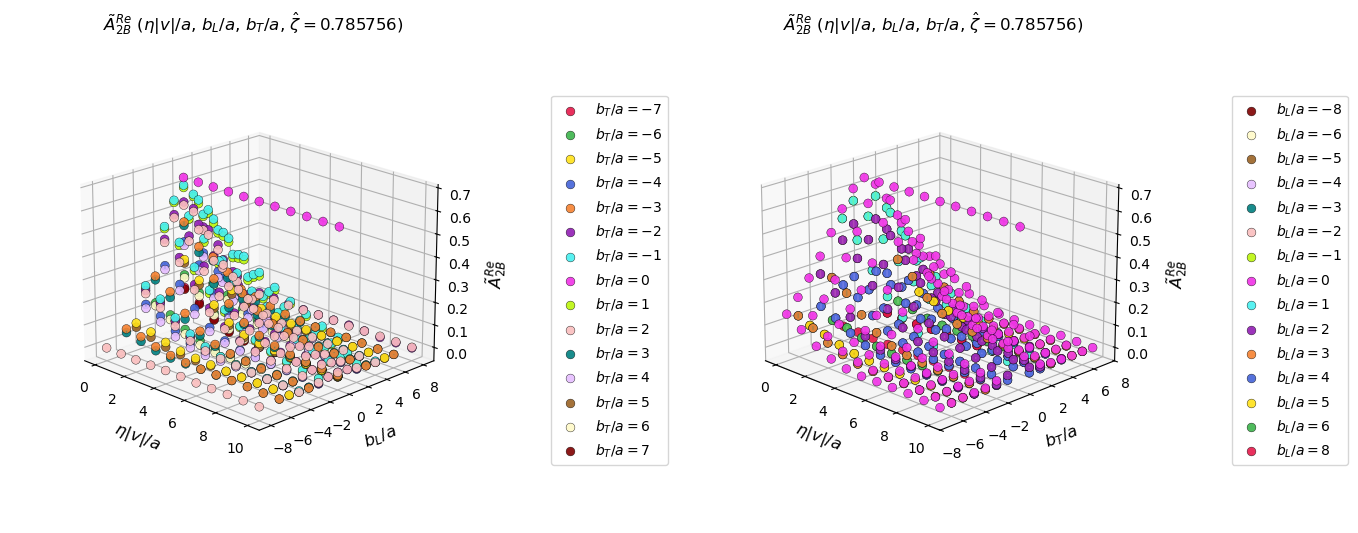

Processing 3D plots for ImA2B...
Saved: ImA2B_PL-4_3D.pdf


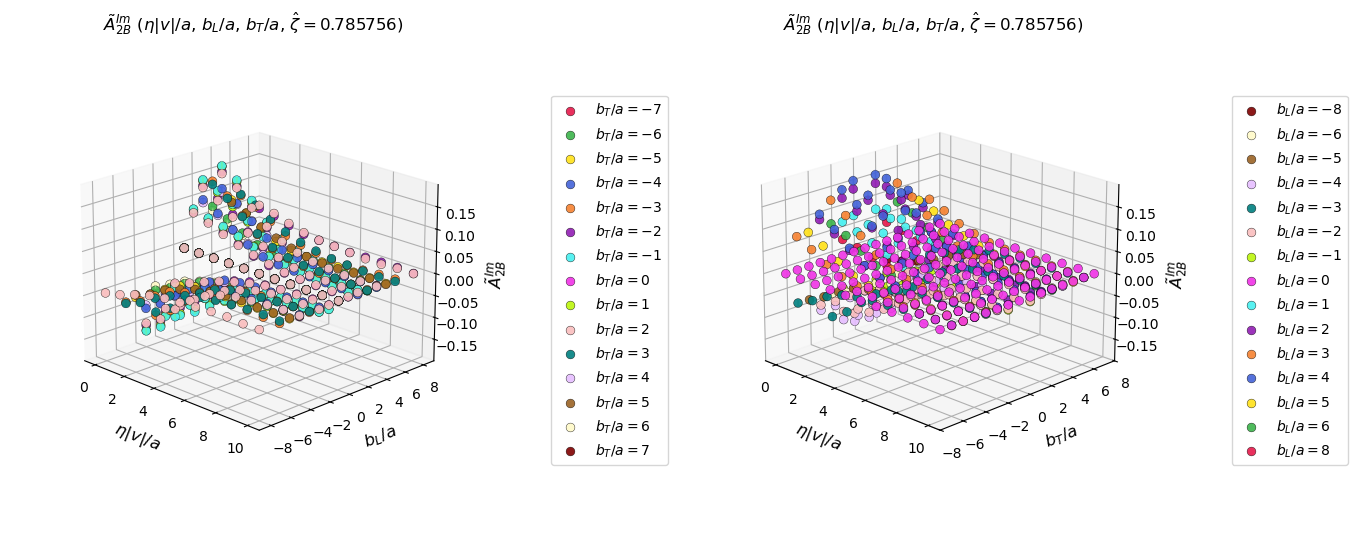

Processing 3D plots for ReA12B...
Saved: ReA12B_PL-4_3D.pdf


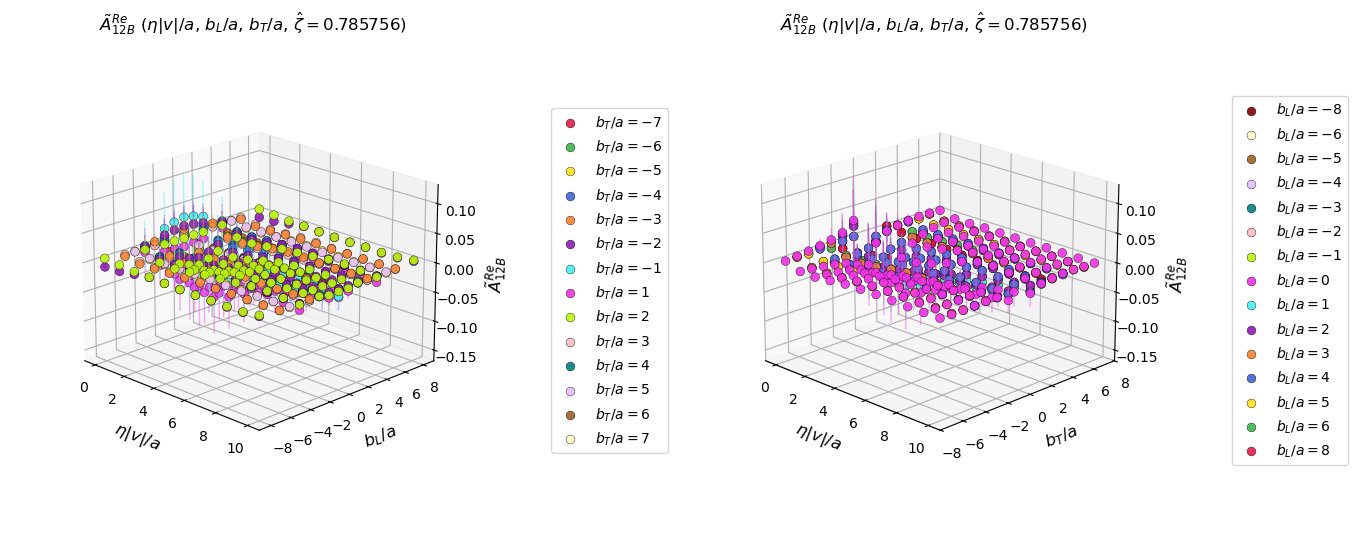

Processing 3D plots for ImA12B...
Saved: ImA12B_PL-4_3D.pdf


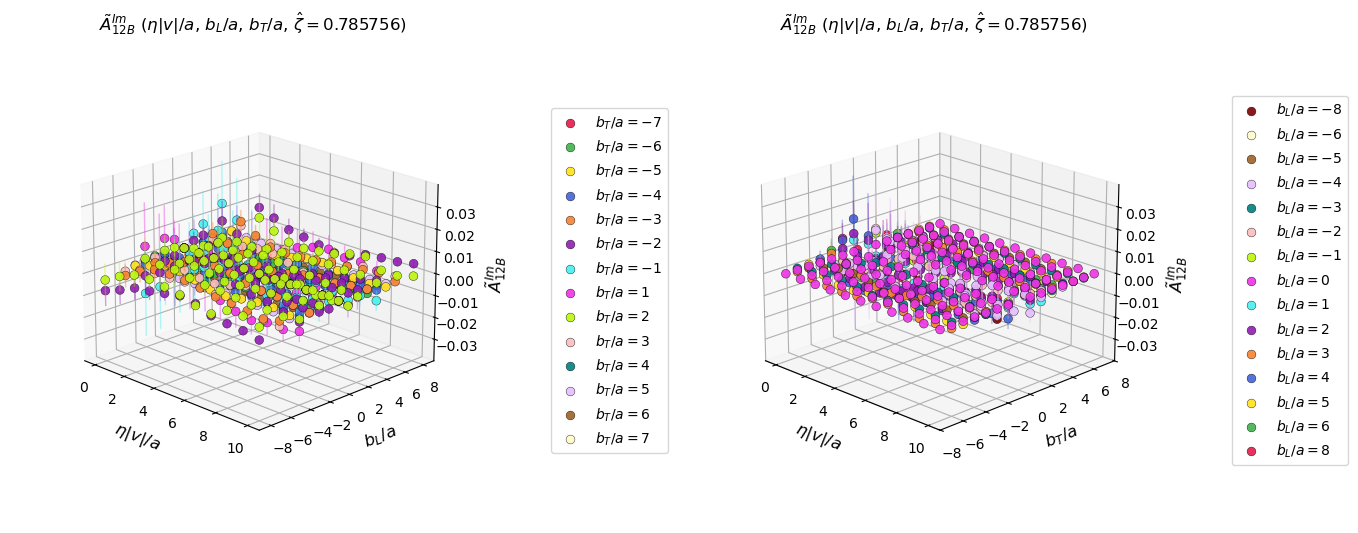

Processing 2D plots at fixed eta=8...
Saved: Combined_eta8_PL-4_2D.pdf


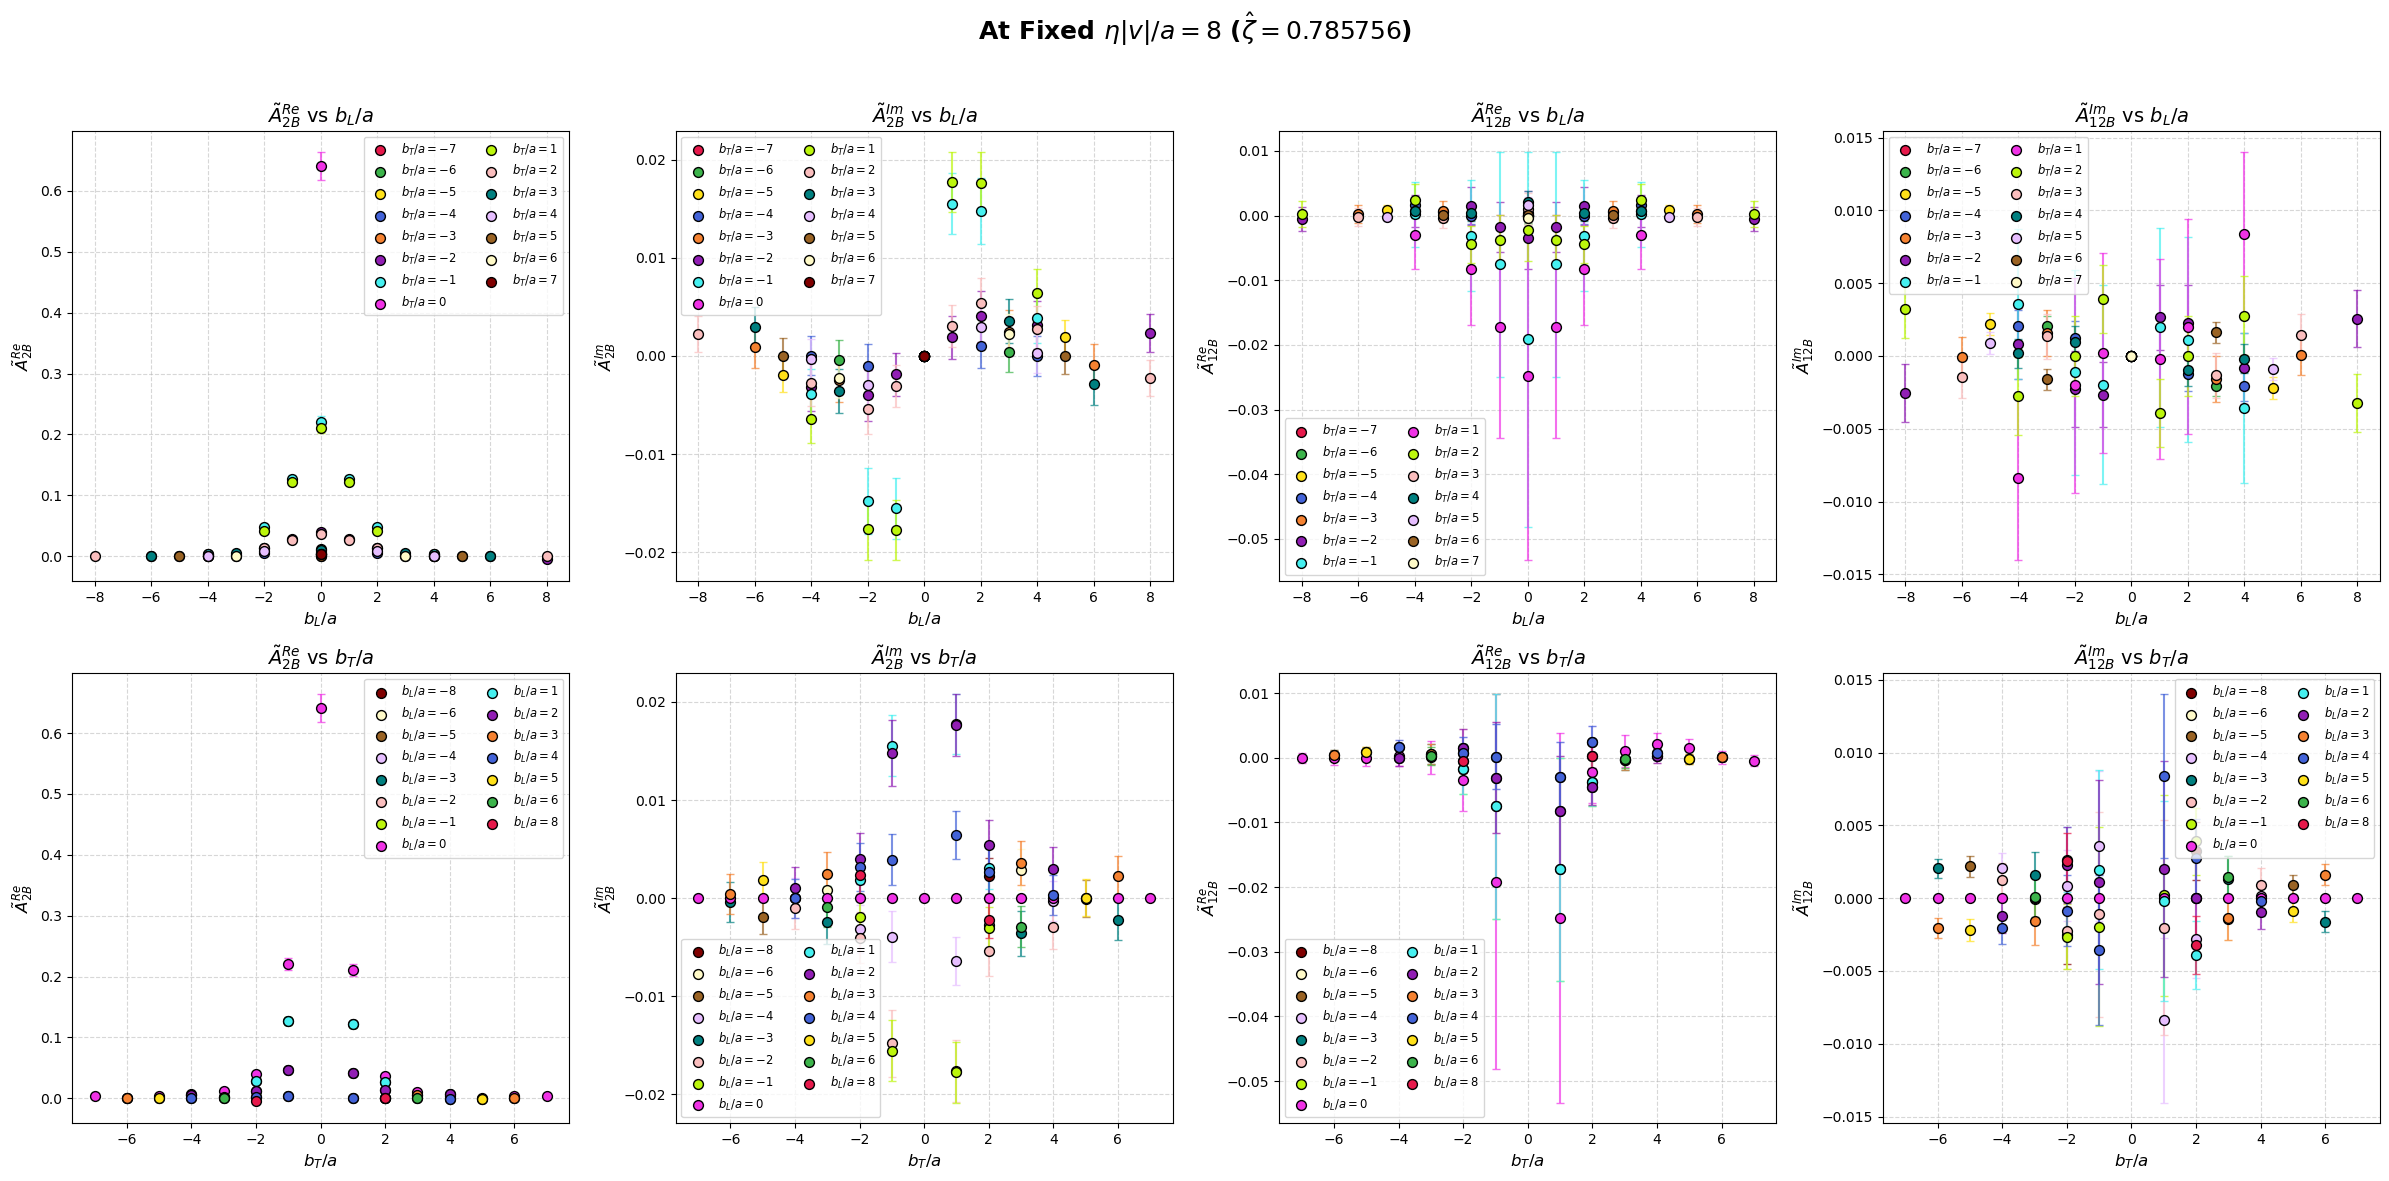

In [20]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- 1. Vectorized Jackknife Function ---
def jackknife_vectorized(samples):
    N = samples.shape[1]
    theta_bar = np.mean(samples, axis=1)
    squared_diffs = np.square(samples - theta_bar[:, None])
    sigma_sq = ((N - 1) / N) * np.sum(squared_diffs, axis=1)
    error = np.sqrt(sigma_sq)
    return theta_bar, error

pl_to_zeta = {
        -4: 0.785756,
        -3: 0.539684,
        -2: 0.294367,
        -1: 0.090772
    }
# --- 2. Data Loading Helper ---
def get_processed_amplitude_data(filepath):
    try:
        with h5py.File(filepath, "r") as f:
            raw_data = f["Dataset1"][:]
    except FileNotFoundError:
        print(f"File not found: {filepath}")
        return None

    kin = raw_data[:, 0:3]
    samples = raw_data[:, 3:]
    
    eta, bL, bT = kin[:, 0], kin[:, 1], kin[:, 2]
    
    # Filter for base eta value from 1 to 10
    mask_eta = (eta >= 0) & (eta <= 10)
    eta_f, bL_f, bT_f = eta[mask_eta], bL[mask_eta], bT[mask_eta]
    
    mean_f, err_f = jackknife_vectorized(samples[mask_eta])
    
    return {
        'eta': eta_f, 'bL': bL_f, 'bT': bT_f,
        'mean': mean_f, 'error': err_f,
        'unique_bL': np.unique(bL_f), 'unique_bT': np.unique(bT_f)
    }

# --- 3. STRICTLY Distinct Color Generator ---
def get_distinct_colors(num_colors):
    """Returns a list of highly distinct, non-gradient colors."""
    distinct_hex = [
        '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231',
        '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe',
        '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000',
        '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080',
        '#000000', '#333333'
    ]
    return [distinct_hex[i % len(distinct_hex)] for i in range(num_colors)]

    

# --- 4. 3D Plotting Function ---
def plot_3d_for_amplitude(data, amp_name, PL):
    fig = plt.figure(figsize=(16, 9))
    
    # Using 'fr' for formatted raw string
    if amp_name == "ReA2B":
        amp_print = "$\\tilde{{A}}_{{2B}}^{{Re}}$"
    elif amp_name == "ImA2B":
        amp_print = "$\\tilde{{A}}_{{2B}}^{{Im}}$"
    elif amp_name == "ReA12B":
        amp_print = "$\\tilde{{A}}_{{12B}}^{{Re}}$"
    elif amp_name == "ImA12B":  # <--- ADD THIS
        amp_print = "$\\tilde{{A}}_{{12B}}^{{Im}}$"
        
    # --- Plot 1: Color by distinct bT ---
    ax1 = fig.add_subplot(121, projection='3d')
    unique_bT = data['unique_bT']
    colors_bT = get_distinct_colors(len(unique_bT))
    
    for i, val_bT in enumerate(unique_bT):
        mask = (data['bT'] == val_bT)
        
        # 1. Plot the mean scatter points
        ax1.scatter(data['eta'][mask], data['bL'][mask], data['mean'][mask], 
                    color=colors_bT[i], label=fr'$b_T/a={val_bT:.0f}$', 
                    s=40, alpha=0.9, edgecolors='k', linewidth=0.3)
                    
        # 2. Add the Z-axis error bars for Jackknife error
        ax1.errorbar(data['eta'][mask], data['bL'][mask], data['mean'][mask], 
                     zerr=data['error'][mask], fmt='none', ecolor=colors_bT[i], 
                     alpha=0.4, linewidth=1.0, zorder=0)

    # Added labelpad=10 to push labels away from tick numbers
    ax1.set_xlabel(r'$\eta|v|/a$', fontsize=12, labelpad=10)
    ax1.set_ylabel(r'$b_L/a$', fontsize=12, labelpad=10)
    ax1.set_zlabel(f'{amp_print}', fontsize=12, labelpad=10)
    ax1.set_title(fr'{amp_print} ($\eta|v|/a$, $b_L/a$, $b_T/a$, $\hat{{\zeta}}={pl_to_zeta[int(PL)]}$)')
    
    # Adjusted legend to be centered vertically on the right to save space
    ax1.legend(loc='center left', bbox_to_anchor=(1.1, 0.5), ncol=1)

    # --- Plot 2: Color by distinct bL ---
    ax2 = fig.add_subplot(122, projection='3d')
    unique_bL = data['unique_bL']
    colors_bL = get_distinct_colors(len(unique_bL))[::-1] 

    for i, val_bL in enumerate(unique_bL):
        mask = (data['bL'] == val_bL)
        
        # 1. Plot the mean scatter points
        ax2.scatter(data['eta'][mask], data['bT'][mask], data['mean'][mask], 
                    color=colors_bL[i], label=fr'$b_L/a={val_bL:.0f}$', 
                    s=40, alpha=0.9, edgecolors='k', linewidth=0.3)

        # 2. Add the Z-axis error bars for Jackknife error
        ax2.errorbar(data['eta'][mask], data['bT'][mask], data['mean'][mask], 
                     zerr=data['error'][mask], fmt='none', ecolor=colors_bL[i], 
                     alpha=0.4, linewidth=1.0, zorder=0)

    # Added labelpad=10
    ax2.set_xlabel(r'$\eta|v|/a$', fontsize=12, labelpad=10)
    ax2.set_ylabel(r'$b_T/a$', fontsize=12, labelpad=10)
    ax2.set_zlabel(f'{amp_print}', fontsize=12, labelpad=10)
    ax2.set_title(fr'{amp_print} ($\eta|v|/a$, $b_L/a$, $b_T/a$, $\hat{{\zeta}}={pl_to_zeta[int(PL)]}$)')
    
    # Adjusted legend
    ax2.legend(loc='center left', bbox_to_anchor=(1.1, 0.5), ncol=1)

    ax1.view_init(elev=20, azim=-45) 
    ax2.view_init(elev=20, azim=-45)

    # --- THE FIX FOR CUT-OFF LABELS ---
    # Shrinks the 3D axes block slightly to leave room for outer labels
    try:
        ax1.set_box_aspect(None, zoom=0.8)
        ax2.set_box_aspect(None, zoom=0.8)
    except AttributeError:
        # Fallback if using an older version of Matplotlib
        ax1.dist = 11
        ax2.dist = 11

    # --- THE FIX FOR SPACING ---
    # Adjusted 'rect' to give slightly more left/bottom margin
    plt.tight_layout(rect=[0.02, 0.05, 0.88, 0.95])
    
    return fig
# --- 5. 2D Plot at fixed eta = 8 ---
def plot_2d_slice_eta8(all_data_dict, PL):
    # Increased figsize width to 24 to comfortably fit 4 columns
    fig, axes = plt.subplots(2, 4, figsize=(24, 12))
    fig.suptitle(fr'At Fixed $\eta|v|/a = 8$ ($\hat{{\zeta}}={pl_to_zeta[int(PL)]}$)', fontsize=18, fontweight='bold')
    
    for idx, (amp_name, data) in enumerate(all_data_dict.items()):
        # Safety catch in case more than 4 items are passed
        if idx >= 4:
            break
            
        if amp_name == "ReA2B":
            amp_print = "$\\tilde{{A}}_{{2B}}^{{Re}}$"
        elif amp_name == "ImA2B":
            amp_print = "$\\tilde{{A}}_{{2B}}^{{Im}}$"
        elif amp_name == "ReA12B":
            amp_print = "$\\tilde{{A}}_{{12B}}^{{Re}}$"
        elif amp_name == "ImA12B":
            amp_print = "$\\tilde{{A}}_{{12B}}^{{Im}}$"
            
        ax_top = axes[0, idx]
        ax_bot = axes[1, idx]
        
        if data is None: 
            ax_top.text(0.5, 0.5, "No data", ha='center', va='center')
            ax_bot.text(0.5, 0.5, "No data", ha='center', va='center')
            continue
        
        mask_eta8 = np.isclose(data['eta'], 8.0)
        bL_8 = data['bL'][mask_eta8]
        bT_8 = data['bT'][mask_eta8]
        mean_8 = data['mean'][mask_eta8]
        err_8 = data['error'][mask_eta8]
        
        if len(bL_8) == 0:
            ax_top.text(0.5, 0.5, "No data", ha='center', va='center')
            ax_bot.text(0.5, 0.5, "No data", ha='center', va='center')
            continue
            
        # ==========================================
        # TOP ROW: Amplitude vs bL, colored by bT
        # ==========================================
        unique_bT = np.unique(bT_8)
        colors_bT = get_distinct_colors(len(unique_bT))
        
        for i, val_bT in enumerate(unique_bT):
            sub_mask = (bT_8 == val_bT)
            ax_top.scatter(bL_8[sub_mask], mean_8[sub_mask], color=colors_bT[i], 
                           label=fr'$b_T/a={val_bT:.0f}$', zorder=5, s=50, edgecolors='k')
            ax_top.errorbar(bL_8[sub_mask], mean_8[sub_mask], yerr=err_8[sub_mask], 
                            fmt='none', ecolor=colors_bT[i], alpha=0.7, zorder=4, capsize=3)
        
        ax_top.set_title(fr'{amp_print} vs $b_L/a$', fontsize=14)
        ax_top.set_xlabel(r'$b_L/a$', fontsize=12)
        ax_top.set_ylabel(f'{amp_print}', fontsize=12)
        ax_top.grid(True, linestyle='--', alpha=0.5)
        ax_top.legend(fontsize='small', loc='best', 
                      ncol=(1 if len(unique_bT) <= 6 else 2))

        # ==========================================
        # BOTTOM ROW: Amplitude vs bT, colored by bL
        # ==========================================
        unique_bL = np.unique(bL_8)
        colors_bL = get_distinct_colors(len(unique_bL))[::-1] 
        
        for i, val_bL in enumerate(unique_bL):
            sub_mask = (bL_8 == val_bL)
            ax_bot.scatter(bT_8[sub_mask], mean_8[sub_mask], color=colors_bL[i], 
                           label=fr'$b_L/a={val_bL:.0f}$', zorder=5, s=50, edgecolors='k')
            ax_bot.errorbar(bT_8[sub_mask], mean_8[sub_mask], yerr=err_8[sub_mask], 
                            fmt='none', ecolor=colors_bL[i], alpha=0.7, zorder=4, capsize=3)
        
        ax_bot.set_title(fr'{amp_print} vs $b_T/a$', fontsize=14)
        ax_bot.set_xlabel(r'$b_T/a$', fontsize=12)
        ax_bot.set_ylabel(f'{amp_print}', fontsize=12)
        ax_bot.grid(True, linestyle='--', alpha=0.5)
        ax_bot.legend(fontsize='small', loc='best', 
                      ncol=(1 if len(unique_bL) <= 6 else 2))

    # Clean up empty subplots if fewer than 4 amplitudes are passed
    num_items = len(all_data_dict)
    for idx in range(num_items, 4):
        axes[0, idx].axis('off')
        axes[1, idx].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    return fig

# ==========================================
# Main Execution Block
# ==========================================
PL_value = "-4" 
path_base = "/pscratch/sd/h/hari_8/TMD_fit/h5data"

amplitude_files = {
    "ReA2B":  f"{path_base}/ReA2B_PL{PL_value}_jackknife_data.h5",
    "ImA2B":  f"{path_base}/ImA2B_PL{PL_value}_jackknife_data.h5",
    "ReA12B": f"{path_base}/ReA12B_PL{PL_value}_jackknife_data.h5",
    "ImA12B": f"{path_base}/ImA12B_PL{PL_value}_jackknife_data.h5"
}

processed_data_store = {}

# 1. Generate and Save 3D Plots
for amp_name, file_path in amplitude_files.items():
    print(f"Processing 3D plots for {amp_name}...")
    amplitude_data = get_processed_amplitude_data(file_path)
    if amplitude_data is not None:
        processed_data_store[amp_name] = amplitude_data
        fig_3d = plot_3d_for_amplitude(amplitude_data, amp_name, PL_value)
        
        # --- SAVE 3D PLOT HERE ---
        save_name_3d = f"{amp_name}_PL{PL_value}_3D.pdf"
        plt.savefig(save_name_3d, format='pdf', dpi=300, bbox_inches='tight')
        print(f"Saved: {save_name_3d}")
        
        plt.show()

# 2. Generate and Save Combined 2D Plots (eta=7)
print("Processing 2D plots at fixed eta=8...")
if processed_data_store:
    fig_2d = plot_2d_slice_eta8(processed_data_store, PL_value)
    
    # --- SAVE 2D PLOT HERE ---
    save_name_2d = f"Combined_eta8_PL{PL_value}_2D.pdf"
    plt.savefig(save_name_2d, format='pdf', dpi=300, bbox_inches='tight')
    print(f"Saved: {save_name_2d}")
    
    plt.show()

Processing 3D plots for ReA2B...
Saved: ReA2B_Pb_bsq_PL-4_3D.pdf


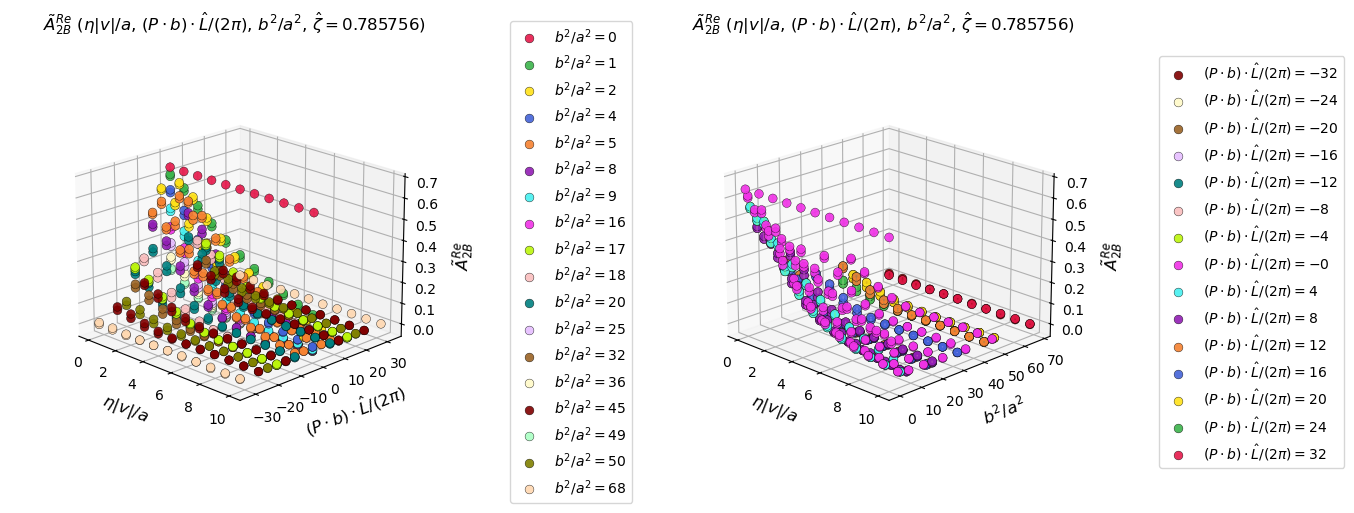

Processing 3D plots for ImA2B...
Saved: ImA2B_Pb_bsq_PL-4_3D.pdf


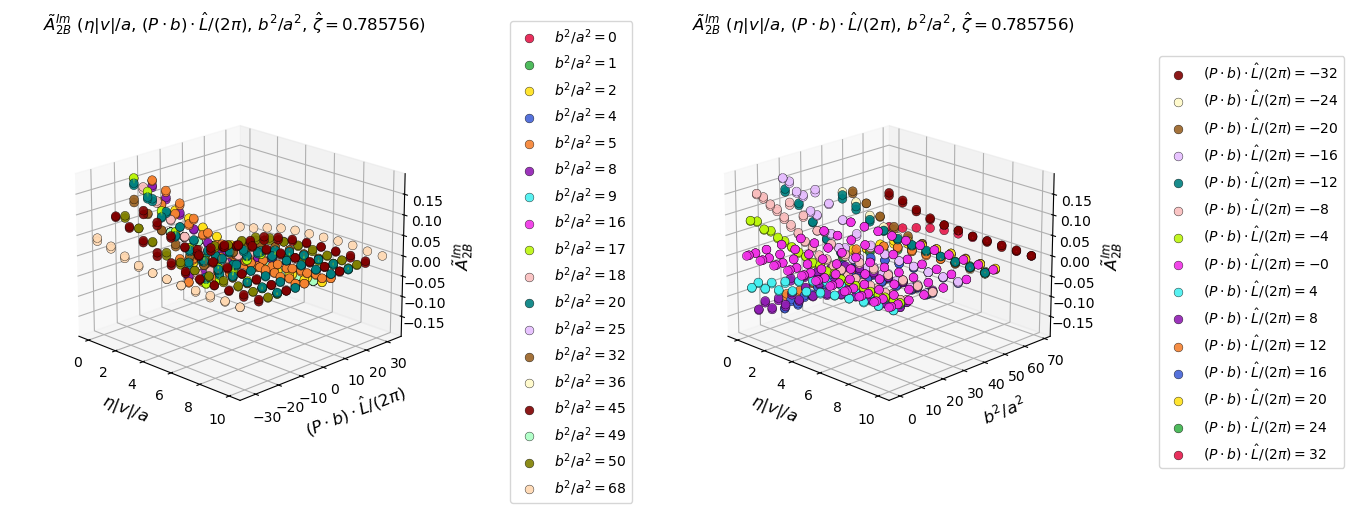

Processing 3D plots for ReA12B...
Saved: ReA12B_Pb_bsq_PL-4_3D.pdf


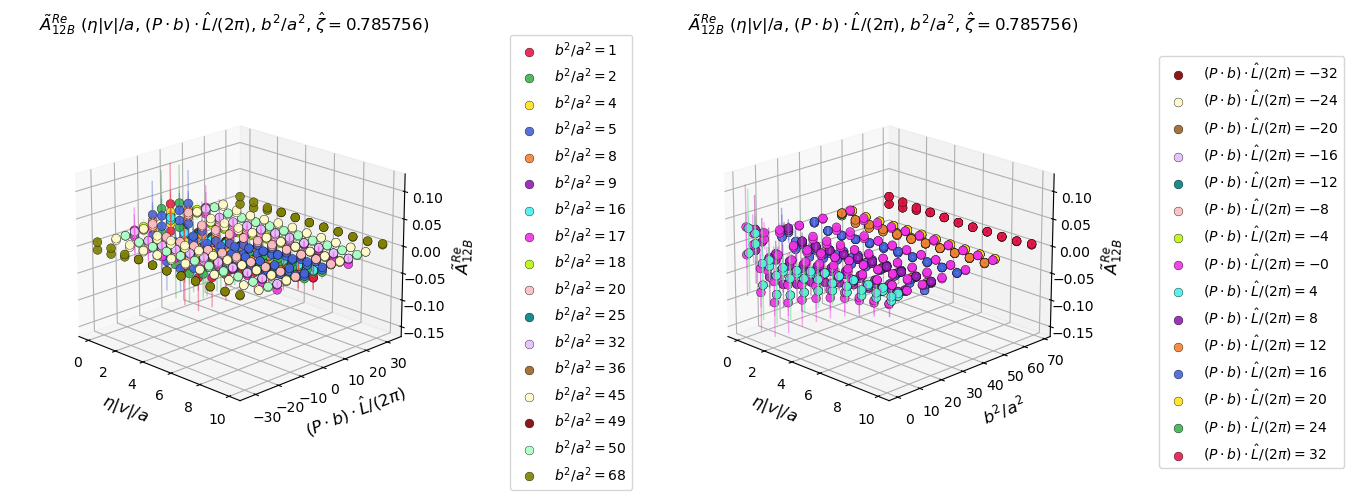

Processing 3D plots for ImA12B...
Saved: ImA12B_Pb_bsq_PL-4_3D.pdf


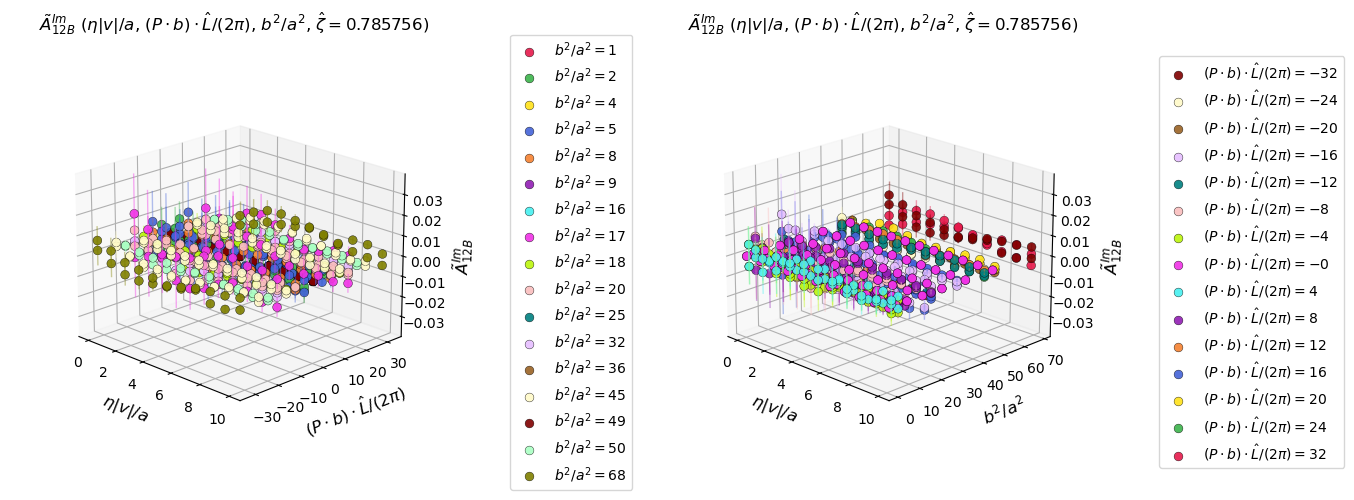

Processing 2D plots at fixed eta=8...
Saved: Combined_Pb_bsq_eta8_PL-4_2D.pdf


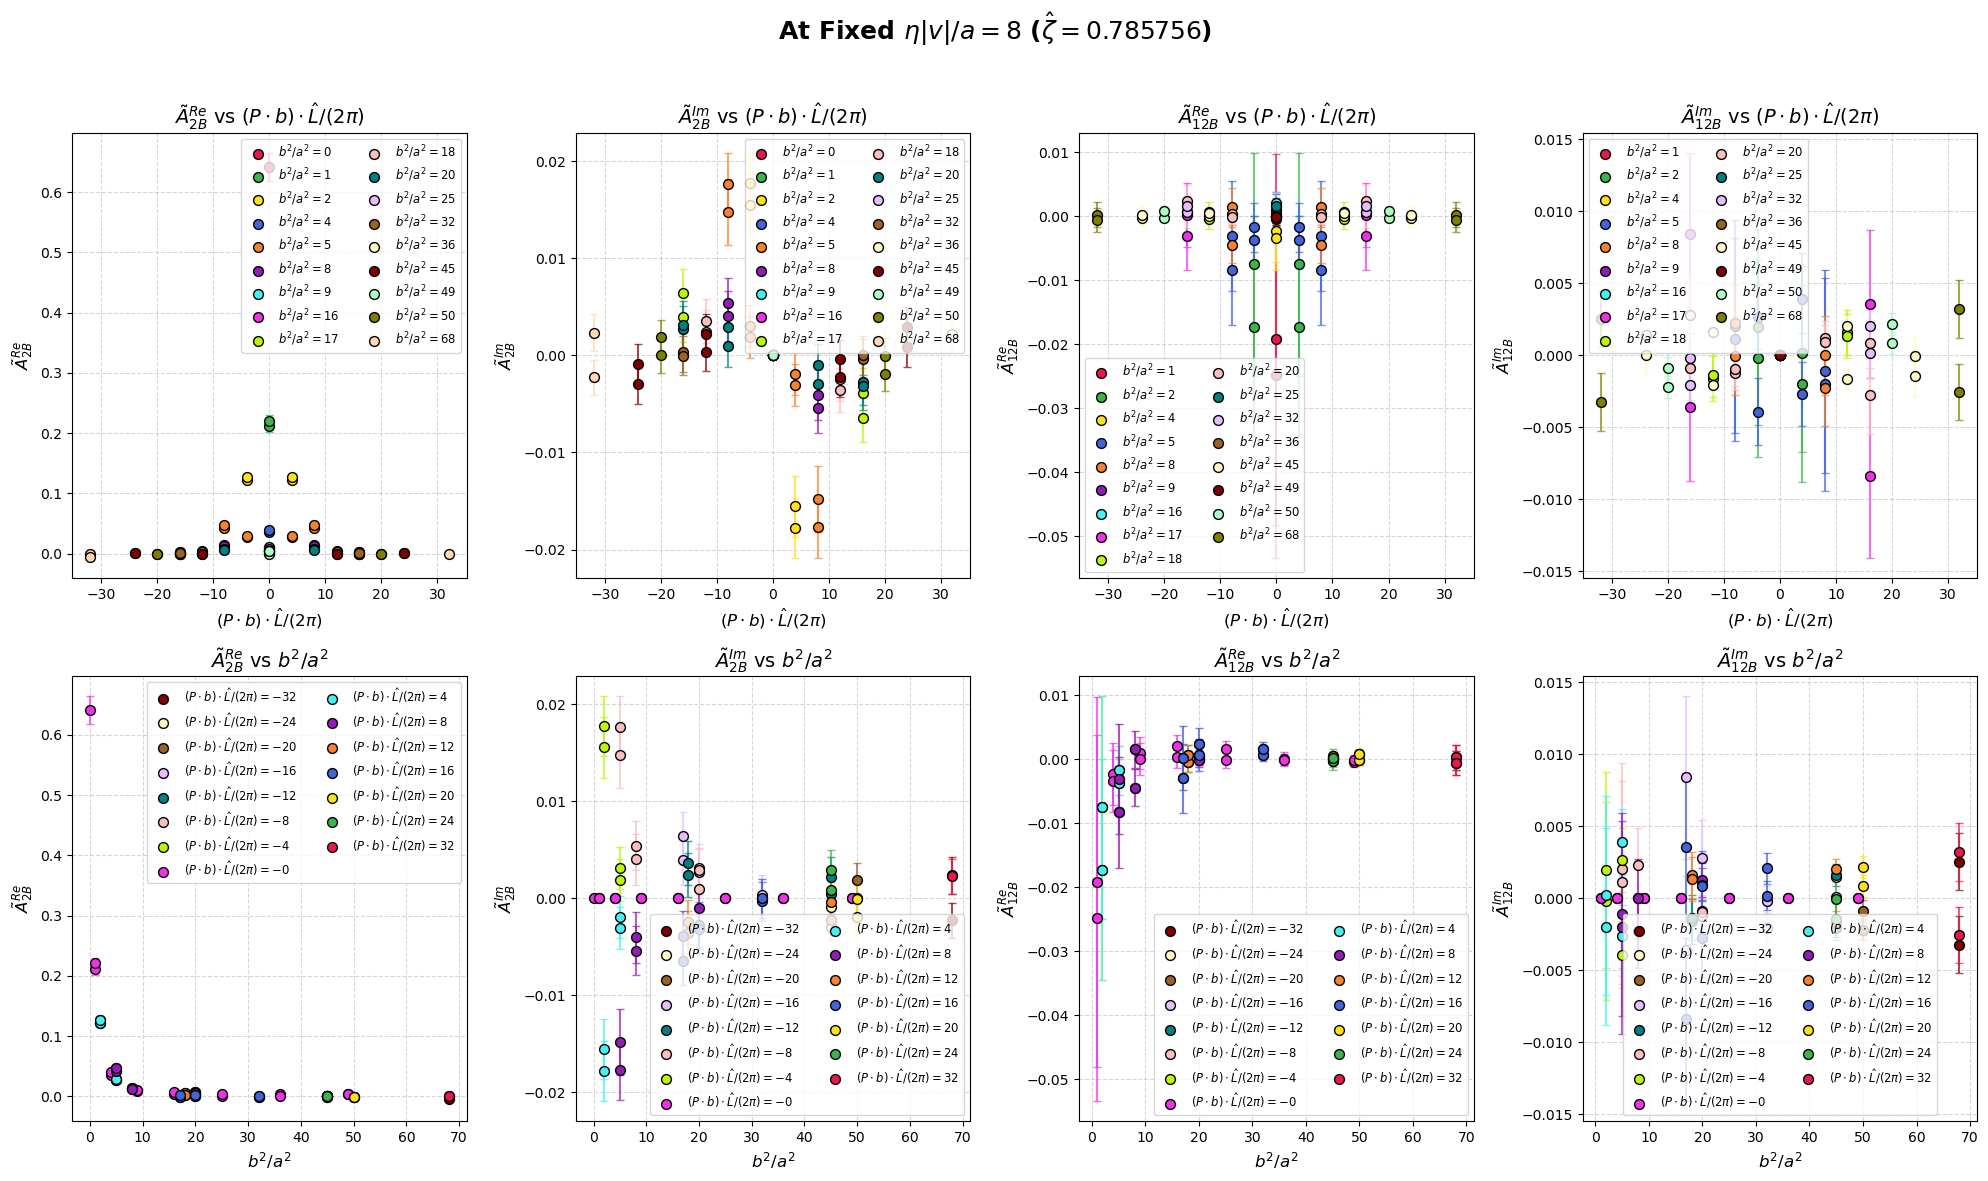

In [21]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- 1. Vectorized Jackknife Function ---
def jackknife_vectorized(samples):
    N = samples.shape[1]
    theta_bar = np.mean(samples, axis=1)
    squared_diffs = np.square(samples - theta_bar[:, None])
    sigma_sq = ((N - 1) / N) * np.sum(squared_diffs, axis=1)
    error = np.sqrt(sigma_sq)
    return theta_bar, error

pl_to_zeta = {
        -4: 0.785756,
        -3: 0.539684,
        -2: 0.294367,
        -1: 0.090772
    }

# --- 2. Data Loading Helper ---
def get_processed_amplitude_data(filepath, PL):
    try:
        with h5py.File(filepath, "r") as f:
            raw_data = f["Dataset1"][:]
    except FileNotFoundError:
        print(f"File not found: {filepath}")
        return None

    kin = raw_data[:, 0:3]
    samples = raw_data[:, 3:]
    
    eta, bL, bT = kin[:, 0], kin[:, 1], kin[:, 2]
    
    # Filter for base eta value from 1 to 10
    mask_eta = (eta >= 0) & (eta <= 10)
    eta_f, bL_f, bT_f = eta[mask_eta], bL[mask_eta], bT[mask_eta]
    
    # Calculate new variables
    # Using np.round to avoid floating point grouping issues in np.unique
    P_dot_b = np.round(bL_f * float(PL), 5)
    b_sq = np.round(bL_f**2 + bT_f**2, 5)
    
    mean_f, err_f = jackknife_vectorized(samples[mask_eta])
    
    return {
        'eta': eta_f, 
        'P_dot_b': P_dot_b, 
        'b_sq': b_sq,
        'mean': mean_f, 
        'error': err_f,
        'unique_P_dot_b': np.unique(P_dot_b), 
        'unique_b_sq': np.unique(b_sq)
    }

# --- 3. STRICTLY Distinct Color Generator ---
def get_distinct_colors(num_colors):
    """Returns a list of highly distinct, non-gradient colors."""
    distinct_hex = [
        '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231',
        '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe',
        '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000',
        '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080',
        '#000000', '#333333'
    ]
    return [distinct_hex[i % len(distinct_hex)] for i in range(num_colors)]

# --- 4. 3D Plotting Function ---
def plot_3d_for_amplitude(data, amp_name, PL):
    fig = plt.figure(figsize=(16, 9))
    
    if amp_name == "ReA2B":
        amp_print = "$\\tilde{{A}}_{{2B}}^{{Re}}$"
    elif amp_name == "ImA2B":
        amp_print = "$\\tilde{{A}}_{{2B}}^{{Im}}$"
    elif amp_name == "ReA12B":
        amp_print = "$\\tilde{{A}}_{{12B}}^{{Re}}$"
    elif amp_name == "ImA12B":
        amp_print = "$\\tilde{{A}}_{{12B}}^{{Im}}$"
        
    # --- Plot 1: Y-axis is P.b, Color by distinct b^2 ---
    ax1 = fig.add_subplot(121, projection='3d')
    unique_b_sq = data['unique_b_sq']
    colors_b_sq = get_distinct_colors(len(unique_b_sq))
    
    for i, val_b_sq in enumerate(unique_b_sq):
        mask = (data['b_sq'] == val_b_sq)
        
        # 1. Plot the mean scatter points
        ax1.scatter(data['eta'][mask], data['P_dot_b'][mask], data['mean'][mask], 
                    color=colors_b_sq[i], label=fr'$b^2/a^2={val_b_sq:g}$', 
                    s=40, alpha=0.9, edgecolors='k', linewidth=0.3)
                    
        # 2. Add the Z-axis error bars for Jackknife error
        ax1.errorbar(data['eta'][mask], data['P_dot_b'][mask], data['mean'][mask], 
                     zerr=data['error'][mask], fmt='none', ecolor=colors_b_sq[i], 
                     alpha=0.4, linewidth=1.0, zorder=0)

    ax1.set_xlabel(r'$\eta|v|/a$', fontsize=12, labelpad=10)
    ax1.set_ylabel(r'$(P \cdot b) \cdot \hat{L} / (2\pi)$', fontsize=12, labelpad=10)
    ax1.set_zlabel(f'{amp_print}', fontsize=12, labelpad=10)
    ax1.set_title(fr'{amp_print} ($\eta|v|/a$, $(P \cdot b)\cdot \hat{{L}} / (2\pi)$, $b^2/a^2$, $\hat{{\zeta}}={pl_to_zeta[int(PL)]}$)')
    ax1.legend(loc='center left', bbox_to_anchor=(1.1, 0.5), ncol=1)

    # --- Plot 2: Y-axis is b^2, Color by distinct P.b ---
    ax2 = fig.add_subplot(122, projection='3d')
    unique_P_dot_b = data['unique_P_dot_b']
    colors_P_dot_b = get_distinct_colors(len(unique_P_dot_b))[::-1] 

    for i, val_P_dot_b in enumerate(unique_P_dot_b):
        mask = (data['P_dot_b'] == val_P_dot_b)
        
        # 1. Plot the mean scatter points
        ax2.scatter(data['eta'][mask], data['b_sq'][mask], data['mean'][mask], 
                    color=colors_P_dot_b[i], label=fr'$(P \cdot b)\cdot \hat{{L}} / (2\pi)={val_P_dot_b:g}$', 
                    s=40, alpha=0.9, edgecolors='k', linewidth=0.3)

        # 2. Add the Z-axis error bars for Jackknife error
        ax2.errorbar(data['eta'][mask], data['b_sq'][mask], data['mean'][mask], 
                     zerr=data['error'][mask], fmt='none', ecolor=colors_P_dot_b[i], 
                     alpha=0.4, linewidth=1.0, zorder=0)

    ax2.set_xlabel(r'$\eta|v|/a$', fontsize=12, labelpad=10)
    ax2.set_ylabel(r'$b^2/a^2$', fontsize=12, labelpad=10)
    ax2.set_zlabel(f'{amp_print}', fontsize=12, labelpad=10)
    ax2.set_title(fr'{amp_print} ($\eta|v|/a$, $(P \cdot b)\cdot \hat{{L}} / (2\pi)$, $b^2/a^2$, $\hat{{\zeta}}={pl_to_zeta[int(PL)]}$)')
    ax2.legend(loc='center left', bbox_to_anchor=(1.1, 0.5), ncol=1)

    ax1.view_init(elev=20, azim=-45) 
    ax2.view_init(elev=20, azim=-45)

    try:
        ax1.set_box_aspect(None, zoom=0.8)
        ax2.set_box_aspect(None, zoom=0.8)
    except AttributeError:
        ax1.dist = 11
        ax2.dist = 11

    plt.tight_layout(rect=[0.02, 0.05, 0.88, 0.95])
    return fig

# --- 5. 2D Plot at fixed eta = 7 ---
def plot_2d_slice_eta7(all_data_dict, PL):
    fig, axes = plt.subplots(2, 4, figsize=(20, 12))
    fig.suptitle(fr'At Fixed $\eta|v|/a = 8$ ($\hat{{\zeta}}={pl_to_zeta[int(PL)]}$)', fontsize=18, fontweight='bold')
    
    for idx, (amp_name, data) in enumerate(all_data_dict.items()):
        if amp_name == "ReA2B":
            amp_print = "$\\tilde{{A}}_{{2B}}^{{Re}}$"
        elif amp_name == "ImA2B":
            amp_print = "$\\tilde{{A}}_{{2B}}^{{Im}}$"
        elif amp_name == "ReA12B":
            amp_print = "$\\tilde{{A}}_{{12B}}^{{Re}}$"
        elif amp_name == "ImA12B":
            amp_print = "$\\tilde{{A}}_{{12B}}^{{Im}}$"
            
        if data is None: continue
        
        ax_top = axes[0, idx]
        ax_bot = axes[1, idx]
        
        mask_eta7 = np.isclose(data['eta'], 8.0)
        P_dot_b_7 = data['P_dot_b'][mask_eta7]
        b_sq_7 = data['b_sq'][mask_eta7]
        mean_7 = data['mean'][mask_eta7]
        err_7 = data['error'][mask_eta7]
        
        if len(P_dot_b_7) == 0:
            ax_top.text(0.5, 0.5, "No data", ha='center', va='center')
            ax_bot.text(0.5, 0.5, "No data", ha='center', va='center')
            continue
            
        # ==========================================
        # TOP ROW: Amplitude vs P.b, colored by b^2
        # ==========================================
        unique_b_sq = np.unique(b_sq_7)
        colors_b_sq = get_distinct_colors(len(unique_b_sq))
        
        for i, val_b_sq in enumerate(unique_b_sq):
            sub_mask = (b_sq_7 == val_b_sq)
            ax_top.scatter(P_dot_b_7[sub_mask], mean_7[sub_mask], color=colors_b_sq[i], 
                           label=fr'$b^2/a^2={val_b_sq:g}$', zorder=5, s=50, edgecolors='k')
            ax_top.errorbar(P_dot_b_7[sub_mask], mean_7[sub_mask], yerr=err_7[sub_mask], 
                            fmt='none', ecolor=colors_b_sq[i], alpha=0.7, zorder=4, capsize=3)
        
        ax_top.set_title(fr'{amp_print} vs $(P \cdot b)\cdot \hat{{L}} / (2\pi)$', fontsize=14)
        ax_top.set_xlabel(r'$(P \cdot b) \cdot \hat{L} / (2\pi)$', fontsize=12)
        ax_top.set_ylabel(f'{amp_print}', fontsize=12)
        ax_top.grid(True, linestyle='--', alpha=0.5)
        ax_top.legend(fontsize='small', loc='best', 
                      ncol=(1 if len(unique_b_sq) <= 6 else 2))

        # ==========================================
        # BOTTOM ROW: Amplitude vs b^2, colored by P.b
        # ==========================================
        unique_P_dot_b = np.unique(P_dot_b_7)
        colors_P_dot_b = get_distinct_colors(len(unique_P_dot_b))[::-1] 
        
        for i, val_P_dot_b in enumerate(unique_P_dot_b):
            sub_mask = (P_dot_b_7 == val_P_dot_b)
            ax_bot.scatter(b_sq_7[sub_mask], mean_7[sub_mask], color=colors_P_dot_b[i], 
                           label=fr'$(P \cdot b)\cdot \hat{{L}} / (2\pi)={val_P_dot_b:g}$', zorder=5, s=50, edgecolors='k')
            ax_bot.errorbar(b_sq_7[sub_mask], mean_7[sub_mask], yerr=err_7[sub_mask], 
                            fmt='none', ecolor=colors_P_dot_b[i], alpha=0.7, zorder=4, capsize=3)
        
        ax_bot.set_title(fr'{amp_print} vs $b^2/a^2$', fontsize=14)
        ax_bot.set_xlabel(r'$b^2/a^2$', fontsize=12)
        ax_bot.set_ylabel(f'{amp_print}', fontsize=12)
        ax_bot.grid(True, linestyle='--', alpha=0.5)
        ax_bot.legend(fontsize='small', loc='best', 
                      ncol=(1 if len(unique_P_dot_b) <= 6 else 2))

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    return fig

# ==========================================
# Main Execution Block
# ==========================================
PL_value = "-4" 
path_base = "/pscratch/sd/h/hari_8/TMD_fit/h5data"

amplitude_files = {
    "ReA2B":  f"{path_base}/ReA2B_PL{PL_value}_jackknife_data.h5",
    "ImA2B":  f"{path_base}/ImA2B_PL{PL_value}_jackknife_data.h5",
    "ReA12B": f"{path_base}/ReA12B_PL{PL_value}_jackknife_data.h5",
    "ImA12B": f"{path_base}/ImA12B_PL{PL_value}_jackknife_data.h5"
}

processed_data_store = {}

# 1. Generate and Save 3D Plots
for amp_name, file_path in amplitude_files.items():
    print(f"Processing 3D plots for {amp_name}...")
    # PASS PL_value so it can calculate P.b correctly
    amplitude_data = get_processed_amplitude_data(file_path, PL_value)
    if amplitude_data is not None:
        processed_data_store[amp_name] = amplitude_data
        fig_3d = plot_3d_for_amplitude(amplitude_data, amp_name, PL_value)
        
        # --- SAVE 3D PLOT HERE ---
        save_name_3d = f"{amp_name}_Pb_bsq_PL{PL_value}_3D.pdf"
        plt.savefig(save_name_3d, format='pdf', dpi=300, bbox_inches='tight')
        print(f"Saved: {save_name_3d}")
        
        plt.show()

# 2. Generate and Save Combined 2D Plots (eta=7)
print("Processing 2D plots at fixed eta=8...")
if processed_data_store:
    fig_2d = plot_2d_slice_eta7(processed_data_store, PL_value)
    
    # --- SAVE 2D PLOT HERE ---
    save_name_2d = f"Combined_Pb_bsq_eta8_PL{PL_value}_2D.pdf"
    plt.savefig(save_name_2d, format='pdf', dpi=300, bbox_inches='tight')
    print(f"Saved: {save_name_2d}")
    
    plt.show()


$\tilde{A}_{2B}^{Re}$ (P_L=-1, eta=8.0):
  P.b=-2 (bL=2), reference b^2=5:
    A(P.b=-2, b^2=8) / A(P.b=-2, b^2=5)  =  0.4962 +/- 0.0062
    A(P.b=-2, b^2=20) / A(P.b=-2, b^2=5)  =  0.1408 +/- 0.0069
  P.b=-4 (bL=4), reference b^2=17:
    A(P.b=-4, b^2=20) / A(P.b=-4, b^2=17)  =  0.7860 +/- 0.0274
    A(P.b=-4, b^2=32) / A(P.b=-4, b^2=17)  =  0.3172 +/- 0.0320

$\tilde{A}_{12B}^{Re}$ (P_L=-1, eta=8.0):
  P.b=-2 (bL=2), reference b^2=5:
    A(P.b=-2, b^2=8) / A(P.b=-2, b^2=5)  =  0.4255 +/- 0.0517
    A(P.b=-2, b^2=20) / A(P.b=-2, b^2=5)  =  0.0977 +/- 0.0294
  P.b=-4 (bL=4), reference b^2=17:
    A(P.b=-4, b^2=20) / A(P.b=-4, b^2=17)  =  0.7028 +/- 0.4667
    A(P.b=-4, b^2=32) / A(P.b=-4, b^2=17)  =  0.5195 +/- 0.4857

$\tilde{A}_{2B}^{Im}$ (P_L=-1, eta=8.0):
  P.b=-2 (bL=2), reference b^2=5:
    A(P.b=-2, b^2=8) / A(P.b=-2, b^2=5)  =  0.5837 +/- 0.0427
    A(P.b=-2, b^2=20) / A(P.b=-2, b^2=5)  =  0.1913 +/- 0.0520
  P.b=-4 (bL=4), reference b^2=17:
    A(P.b=-4, b^2=20) / A(P.b=-4, b

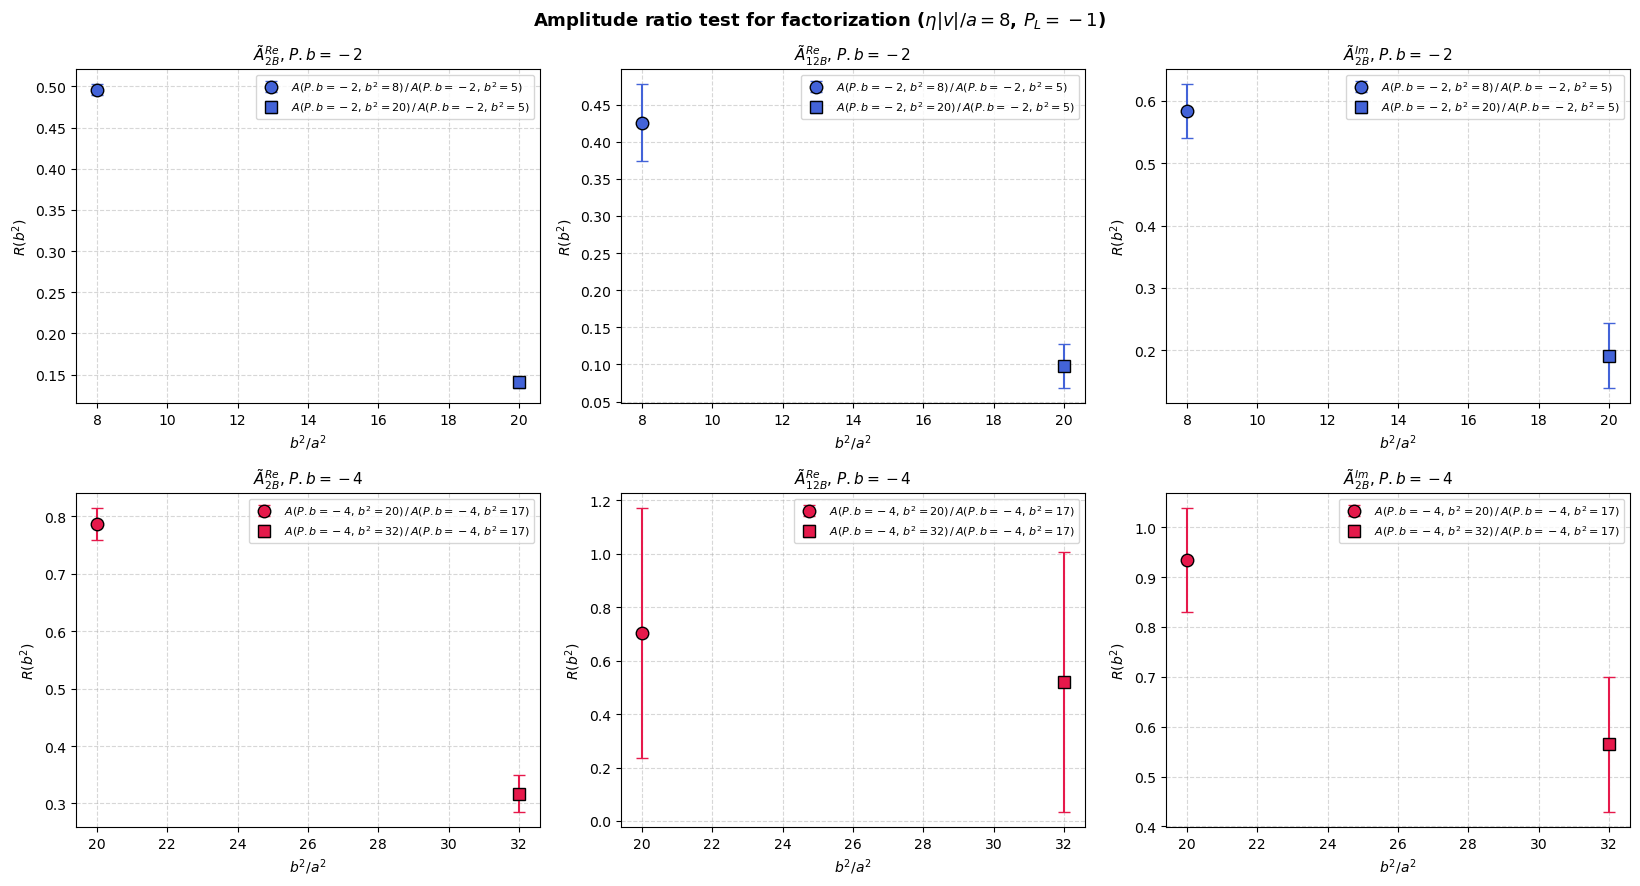

In [7]:
# ---------------------------------------------------------------------------
# Amplitude ratio test for factorization.
#
# For a FIXED P.b (fixed bL), the amplitude A(bL,bT) is already measured at
# several real b^2 values (varying bT) in that same row -- no cross-row
# matching or interpolation needed. Ratio the other b^2 values in the row
# against the row's own smallest b^2 (the reference, b3):
#
#     R(b_i) = A(P.b, b_i) / A(P.b, b3)
#
# Under exact factorization A(P.b,b^2)=F(P.b)G(b^2), this equals G(b_i)/G(b3)
# -- independent of P.b. Two separate P.b's are shown as separate panels
# (P.b=-2 and P.b=-4) so you can compare their b^2-shape directly; they
# don't share all their b^2 values, so this is a shape comparison, not a
# literal same-number check -- where a b^2 value happens to coincide across
# rows (e.g. b^2=20 here), it was ratioed against a DIFFERENT reference in
# each row, so the two numbers aren't directly comparable as-is.
#
# Rows used (eta=8, PL=-1, canonical bL>=0):
#     P.b=-2 (bL=2): b^2 = 5, 8, 20   -> reference b3=5  (smallest)
#     P.b=-4 (bL=4): b^2 = 17, 20, 32 -> reference b3=17 (smallest)
#
# Canonicalization: each b^2 in a row is hit by BOTH bT and -bT, and bT-sign
# is NOT a symmetry of these amplitudes (values genuinely differ) -- so bT>0
# is used consistently (unambiguous here since no bT=0 rows exist at
# bL=2,4). The ratio is formed per jackknife sample first, then reduced
# with jackknife_vectorized() (verbatim from the cells above). No fit,
# line, or mean is applied to the points.
#
# Marker convention: color = P.b (blue=-2, red=-4); shape = which point
# within the row (circle = first/lower-b^2 ratio, square = second), the
# same shape sequence used in both rows.
# ---------------------------------------------------------------------------
import h5py
import numpy as np
import matplotlib.pyplot as plt

path_base = "/Users/hariprashadravikumar/Lattice_QCD_TMD_PhD/sivers_TMD_PhD_project/save_h5_A12B_A2B/TMD_fit/h5data"

ETA_SLICE = 8.0
PL_TEST = -1
AMPLITUDES_TEST = ["ReA2B", "ReA12B", "ImA2B"]
BL_LIST = [2, 4]   # the two P.b rows

AMP_PRINT = {
    "ReA2B": r"$\tilde{A}_{2B}^{Re}$", "ImA2B": r"$\tilde{A}_{2B}^{Im}$",
    "ReA12B": r"$\tilde{A}_{12B}^{Re}$", "ImA12B": r"$\tilde{A}_{12B}^{Im}$",
}


def jackknife_vectorized(samples):
    """Same jackknife error formula used throughout this notebook.
    samples: (n_points, N_JK)."""
    N = samples.shape[1]
    theta_bar = np.mean(samples, axis=1)
    squared_diffs = np.square(samples - theta_bar[:, None])
    sigma_sq = ((N - 1) / N) * np.sum(squared_diffs, axis=1)
    error = np.sqrt(sigma_sq)
    return theta_bar, error


def load_eta_slice(amp_name, pl, eta_slice, data_dir=path_base):
    filepath = f"{data_dir}/{amp_name}_PL{pl}_jackknife_data.h5"
    with h5py.File(filepath, "r") as f:
        raw = f["Dataset1"][:]
    kin = raw[:, 0:3]
    eta, bL, bT = kin[:, 0], kin[:, 1], kin[:, 2]
    samples = raw[:, 3:]
    mask = np.isclose(eta, eta_slice)
    return bL[mask], bT[mask], samples[mask]


def rows_for_bL(bL, bT, samples, blv):
    """
    All (b^2, sample-row) entries for a fixed bL >= 0, canonicalized to
    bT > 0. Each b^2 value in this data is hit by BOTH bT and -bT, and
    bT-sign is NOT a symmetry (amplitude values genuinely differ) -- so we
    pick one consistently rather than let array order decide it. bT > 0
    gives a unique b^2 per row here (no bT=0 rows at bL=2,4).
    """
    m = np.isclose(bL, blv) & (bT > 0)
    bT_row = bT[m]
    samples_row = samples[m]
    b2_row = blv**2 + bT_row**2

    order = np.argsort(b2_row)
    return b2_row[order], samples_row[order]


def run_fixed_Pb_ratio_test(amp_name, bl_list=BL_LIST, pl=PL_TEST, eta_slice=ETA_SLICE):
    bL, bT, samples = load_eta_slice(amp_name, pl, eta_slice)
    keep = bL >= 0
    bL, bT, samples = bL[keep], bT[keep], samples[keep]

    print(f"\n{AMP_PRINT.get(amp_name, amp_name)} (P_L={pl}, eta={eta_slice}):")
    all_results = {}
    for blv in bl_list:
        b2_vals, sample_rows = rows_for_bL(bL, bT, samples, blv)
        b3 = b2_vals[0]                 # smallest b^2 = reference
        others = b2_vals[1:]
        ref_samples = sample_rows[0]

        ratio_samples = np.stack([sample_rows[i] / ref_samples for i in range(1, len(b2_vals))])
        means, errs = jackknife_vectorized(ratio_samples)

        Pb = blv * pl
        print(f"  P.b={Pb:+.0f} (bL={blv:.0f}), reference b^2={b3:.0f}:")
        results = []
        for b_i, mean, err in zip(others, means, errs):
            print(f"    A(P.b={Pb:+.0f}, b^2={b_i:.0f}) / A(P.b={Pb:+.0f}, b^2={b3:.0f})"
                  f"  =  {mean:.4f} +/- {err:.4f}")
            results.append({'b2': b_i, 'b3': b3, 'Pb': Pb, 'mean': mean, 'err': err})
        all_results[blv] = results

    return all_results


def plot_fixed_Pb_ratios(all_amp_results, pl=PL_TEST, eta_slice=ETA_SLICE):
    """
    One row per P.b (blue=P.b=-2, red=P.b=-4), one column per amplitude --
    separate panels. Color = P.b; shape = point index within the row
    (circle = first ratio, square = second), same shape sequence in both
    rows. Every point's legend entry spells out the literal ratio.
    """
    colors_by_bL = {2: '#4363d8', 4: '#e6194b'}
    point_markers = ['o', 's', '^', 'D']   # circle, square, ... by point index within a row
    bl_list = list(next(iter(all_amp_results.values())).keys())
    amps = list(all_amp_results.keys())
    n_amp = len(amps)
    n_bl = len(bl_list)

    fig, axes = plt.subplots(n_bl, n_amp, figsize=(5.5 * n_amp, 4.5 * n_bl), squeeze=False)

    for row, blv in enumerate(bl_list):
        color = colors_by_bL.get(blv, '#333333')
        for col, amp_name in enumerate(amps):
            ax = axes[row, col]
            results = all_amp_results[amp_name][blv]

            for i, r in enumerate(results):
                marker = point_markers[i % len(point_markers)]
                eq_label = fr"$A(P.b={r['Pb']:+.0f},\,b^2={r['b2']:.0f}) \,/\, " \
                           fr"A(P.b={r['Pb']:+.0f},\,b^2={r['b3']:.0f})$"
                ax.errorbar([r['b2']], [r['mean']], yerr=[r['err']], fmt=marker,
                            color=color, capsize=4, markersize=9,
                            markeredgecolor='k', zorder=5, label=eq_label)

            Pb = results[0]['Pb']
            ax.set_title(fr'{AMP_PRINT.get(amp_name, amp_name)}, $P.b={Pb:+.0f}$',
                         fontsize=11)
            ax.set_xlabel(r'$b^2/a^2$')
            ax.set_ylabel(r'$R(b^2)$')
            ax.grid(True, linestyle='--', alpha=0.5)
            ax.legend(fontsize=8)

    fig.suptitle(fr'Amplitude ratio test for factorization ($\eta|v|/a={eta_slice:.0f}$, $P_L={pl}$)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"FixedPb_Bsq_RatioTest_eta{int(eta_slice)}_PL{pl}.pdf",
                format='pdf', bbox_inches='tight')
    return fig


all_amp_results = {amp: run_fixed_Pb_ratio_test(amp) for amp in AMPLITUDES_TEST}
plot_fixed_Pb_ratios(all_amp_results)
plt.show()


In [9]:
import h5py
import numpy as np

FILEPATH = "../h5data/ReA2B_PL-1_jackknife_data.h5"
PL = -1
ETA = 8


def main():
    with h5py.File(FILEPATH, "r") as f:
        kin = f["Dataset1"][:, 0:3]

    eta, bL, bT = kin[:, 0], kin[:, 1], kin[:, 2]
    mask = np.isclose(eta, ETA)
    bL_f, bT_f = bL[mask], bT[mask]

    P_dot_b = np.round(bL_f * PL, 5) + 0.0  # normalize -0.0 to 0.0
    b_sq = np.round(bL_f**2 + bT_f**2, 5)

    pairs = sorted(set(zip(P_dot_b.tolist(), b_sq.tolist())), key=lambda p: (p[0], p[1]))

    grouped = {}
    for pb, bsq in pairs:
        grouped.setdefault(pb, []).append(bsq)

    print(f"eta={ETA}, PL={PL}: {len(pairs)} unique (P.b, b^2) pairs\n")
    for pb in sorted(grouped):
        bsq_list = ", ".join(f"{v:g}" for v in grouped[pb])
        print(f"P.b = {pb:g}, b^2 = {bsq_list}")


if __name__ == "__main__":
    main()


eta=8, PL=-1: 34 unique (P.b, b^2) pairs

P.b = -8, b^2 = 68
P.b = -6, b^2 = 45
P.b = -5, b^2 = 50
P.b = -4, b^2 = 17, 20, 32
P.b = -3, b^2 = 18, 45
P.b = -2, b^2 = 5, 8, 20
P.b = -1, b^2 = 2, 5
P.b = 0, b^2 = 0, 1, 4, 9, 16, 25, 36, 49
P.b = 1, b^2 = 2, 5
P.b = 2, b^2 = 5, 8, 20
P.b = 3, b^2 = 18, 45
P.b = 4, b^2 = 17, 20, 32
P.b = 5, b^2 = 50
P.b = 6, b^2 = 45
P.b = 8, b^2 = 68
